# Importing all Dependencies

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns


# Loading Dataset: MyAnimeList

In [2]:
df=pd.read_csv(r"C:\Users\Dell\Downloads\Data Analyst\Skills\Chandoo\MyAnimeList.csv")
df

,anime_id,title,title_english,title_japanese,title_synonyms,image_url,type,source,episodes,status,...,background,premiered,broadcast,related,producer,licensor,studio,genre,opening_theme,ending_theme
0,1535,Death Note,Death Note,デスノート,DN,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,37,Finished Airing,...,Death Note has been adapted into live action f...,Fall 2006,Wednesdays at 00:56 (JST),"{'Adaptation': [{'mal_id': 21, 'type': 'manga'...","VAP, Konami, Ashi Production, Nippon Televisio...",Viz Media,Madhouse,"Mystery, Police, Psychological, Supernatural, ...","['#1: ""the WORLD"" by Nightmare (eps 1-19)', '#...","['#1: ""Alumina"" by Nightmare (eps 1-19)', '#2:..."
1,16498,Shingeki no Kyojin,Attack on Titan,進撃の巨人,AoT,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,25,Finished Airing,...,Shingeki no Kyojin adapts content from the fir...,Spring 2013,Sundays at 01:58 (JST),"{'Adaptation': [{'mal_id': 23390, 'type': 'man...","Production I.G, Dentsu, Mainichi Broadcasting ...",Funimation,Wit Studio,"Action, Military, Mystery, Super Power, Drama,...","['#1: ""Guren no Yumiya (紅蓮の弓矢)"" by Linked Hori...","['#1: ""Utsukushiki Zankoku na Sekai (美しき残酷な世界)..."
2,11757,Sword Art Online,Sword Art Online,ソードアート・オンライン,"S.A.O, SAO",https://myanimelist.cdn-dena.com/images/anime/...,TV,Light novel,25,Finished Airing,...,Sword Art Online adapts the first 4 novels of ...,Summer 2012,Sundays at 00:00 (JST),"{'Adaptation': [{'mal_id': 21479, 'type': 'man...","Aniplex, Genco, DAX Production, ASCII Media Works",Aniplex of America,A-1 Pictures,"Action, Adventure, Fantasy, Game, Romance","['#1: ""crossing field"" by LiSA (eps 2-14)', '#...","['#1: ""crossing field"" by LiSA (eps 1, 25)', '..."
3,5114,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,"Hagane no Renkinjutsushi: Fullmetal Alchemist,...",https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,64,Finished Airing,...,Fullmetal Alchemist: Brotherhood is an alterna...,Spring 2009,Sundays at 17:00 (JST),"{'Adaptation': [{'mal_id': 25, 'type': 'manga'...","Aniplex, Square Enix, Mainichi Broadcasting Sy...","Funimation, Aniplex of America",Bones,"Action, Military, Adventure, Comedy, Drama, Ma...","['#1: ""again"" by YUI (eps 1-14)', '#2: ""Hologr...","['#1: ""Uso (嘘)"" by SID (eps 1-14)', '#2: ""LET ..."
4,30276,One Punch Man,One Punch Man,ワンパンマン,"One Punch-Man, One-Punch Man, OPM",https://myanimelist.cdn-dena.com/images/anime/...,TV,Web manga,12,Finished Airing,...,Episodes 1 and 2 were previewed at a screening...,Fall 2015,Mondays at 01:05 (JST),"{'Adaptation': [{'mal_id': 44347, 'type': 'man...","TV Tokyo, Bandai Visual, Lantis, Asatsu DK, Ba...",Viz Media,Madhouse,"Action, Sci-Fi, Comedy, Parody, Super Power, S...","['""THE HERO !! ~Okoreru Kobushi ni Hi wo Tsuke...","['#1: ""Hoshi yori Saki ni Mitsukete Ageru (星より..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14469,35853,Zero Seiki Movie 1: Emeraldas,NaN,零世紀 エメラルダス,"The Zero Century Movie 1: Emeraldas, The Zero ...",https://myanimelist.cdn-dena.com/images/anime/...,Movie,Manga,1,Not yet aired,...,NaN,NaN,NaN,"{'Adaptation': [{'mal_id': 26486, 'type': 'man...",NaN,NaN,NaN,"Action, Sci-Fi, Adventure",[],[]
14470,35854,Zero Seiki Movie 2: Herlock,NaN,零世紀 ハーロック,"The Zero Century: Harlock, The Zero Century Mo...",https://myanimelist.cdn-dena.com/images/anime/...,Movie,Manga,1,Not yet aired,...,NaN,NaN,NaN,"{'Adaptation': [{'mal_id': 5115, 'type': 'mang...",NaN,NaN,NaN,"Action, Sci-Fi, Adventure",[],[]
14471,35855,Zero Seiki Movie 3: Maetel,NaN,零世紀 メーテル,"The Zero Century Movie 3: Maetel, The Zero Cen...",https://myanimelist.cdn-dena.com/images/anime/...,Movie,Manga,1,Not yet aired,...,NaN,NaN,NaN,"{'Other': [{'mal_id': 1495, 'type': 'anime', '...",NaN,NaN,NaN,"Action, Sci-Fi, Adventure",[],[]
14472,37395,Zoids Wild,NaN,ゾイドワイルド,NaN,https://myanimelist.cdn-dena.com/images/anime/...,TV,Unknown,0,Not yet aired,...,NaN,Summer 2018,Unknow

# Intitial Exploration

In [3]:
# Exploring the first five rows of our dataset

df.head()

,anime_id,title,title_english,title_japanese,title_synonyms,image_url,type,source,episodes,status,...,background,premiered,broadcast,related,producer,licensor,studio,genre,opening_theme,ending_theme
0,1535,Death Note,Death Note,デスノート,DN,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,37,Finished Airing,...,Death Note has been adapted into live action f...,Fall 2006,Wednesdays at 00:56 (JST),"{'Adaptation': [{'mal_id': 21, 'type': 'manga'...","VAP, Konami, Ashi Production, Nippon Televisio...",Viz Media,Madhouse,"Mystery, Police, Psychological, Supernatural, ...","['#1: ""the WORLD"" by Nightmare (eps 1-19)', '#...","['#1: ""Alumina"" by Nightmare (eps 1-19)', '#2:..."
1,16498,Shingeki no Kyojin,Attack on Titan,進撃の巨人,AoT,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,25,Finished Airing,...,Shingeki no Kyojin adapts content from the fir...,Spring 2013,Sundays at 01:58 (JST),"{'Adaptation': [{'mal_id': 23390, 'type': 'man...","Production I.G, Dentsu, Mainichi Broadcasting ...",Funimation,Wit Studio,"Action, Military, Mystery, Super Power, Drama,...","['#1: ""Guren no Yumiya (紅蓮の弓矢)"" by Linked Hori...","['#1: ""Utsukushiki Zankoku na Sekai (美しき残酷な世界)..."
2,11757,Sword Art Online,Sword Art Online,ソードアート・オンライン,"S.A.O, SAO",https://myanimelist.cdn-dena.com/images/anime/...,TV,Light novel,25,Finished Airing,...,Sword Art Online adapts the first 4 novels of ...,Summer 2012,Sundays at 00:00 (JST),"{'Adaptation': [{'mal_id': 21479, 'type': 'man...","Aniplex, Genco, DAX Production, ASCII Media Works",Aniplex of America,A-1 Pictures,"Action, Adventure, Fantasy, Game, Romance","['#1: ""crossing field"" by LiSA (eps 2-14)', '#...","['#1: ""crossing field"" by LiSA (eps 1, 25)', '..."
3,5114,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,"Hagane no Renkinjutsushi: Fullmetal Alchemist,...",https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,64,Finished Airing,...,Fullmetal Alchemist: Brotherhood is an alterna...,Spring 2009,Sundays at 17:00 (JST),"{'Adaptation': [{'mal_id': 25, 'type': 'manga'...","Aniplex, Square Enix, Mainichi Broadcasting Sy...","Funimation, Aniplex of America",Bones,"Action, Military, Adventure, Comedy, Drama, Ma...","['#1: ""again"" by YUI (eps 1-14)', '#2: ""Hologr...","['#1: ""Uso (嘘)"" by SID (eps 1-14)', '#2: ""LET ..."
4,30276,One Punch Man,One Punch Man,ワンパンマン,"One Punch-Man, One-Punch Man, OPM",https://myanimelist.cdn-dena.com/images/anime/...,TV,Web manga,12,Finished Airing,...,Episodes 1 and 2 were previewed at a screening...,Fall 2015,Mondays at 01:05 (JST),"{'Adaptation': [{'mal_id': 44347, 'type': 'man...","TV Tokyo, Bandai Visual, Lantis, Asatsu DK, Ba...",Viz Media,Madhouse,"Action, Sci-Fi, Comedy, Parody, Super Power, S...","['""THE HERO !! ~Okoreru Kobushi ni Hi wo Tsuke...","['#1: ""Hoshi yori Saki ni Mitsukete Ageru (星より..."


In [4]:
# Exploring the last five rows of our dataset

df.tail()

,anime_id,title,title_english,title_japanese,title_synonyms,image_url,type,source,episodes,status,...,background,premiered,broadcast,related,producer,licensor,studio,genre,opening_theme,ending_theme
14469,35853,Zero Seiki Movie 1: Emeraldas,NaN,零世紀 エメラルダス,"The Zero Century Movie 1: Emeraldas, The Zero ...",https://myanimelist.cdn-dena.com/images/anime/...,Movie,Manga,1,Not yet aired,...,NaN,NaN,NaN,"{'Adaptation': [{'mal_id': 26486, 'type': 'man...",NaN,NaN,NaN,"Action, Sci-Fi, Adventure",[],[]
14470,35854,Zero Seiki Movie 2: Herlock,NaN,零世紀 ハーロック,"The Zero Century: Harlock, The Zero Century Mo...",https://myanimelist.cdn-dena.com/images/anime/...,Movie,Manga,1,Not yet aired,...,NaN,NaN,NaN,"{'Adaptation': [{'mal_id': 5115, 'type': 'mang...",NaN,NaN,NaN,"Action, Sci-Fi, Adventure",[],[]
14471,35855,Zero Seiki Movie 3: Maetel,NaN,零世紀 メーテル,"The Zero Century Movie 3: Maetel, The Zero Cen...",https://myanimelist.cdn-dena.com/images/anime/...,Movie,Manga,1,Not yet aired,...,NaN,NaN,NaN,"{'Other': [{'mal_id': 1495, 'type': 'anime', '...",NaN,NaN,NaN,"Action, Sci-Fi, Adventure",[],[]
14472,37395,Zoids Wild,NaN,ゾイドワイルド,NaN,https://myanimelist.cdn-dena.com/images/anime/...,TV,Unknown,0,Not yet aired,...,NaN,Summer 2018,Unknown,"{'Adaptation': [{'mal_id': 112949, 'type': 'ma...",NaN,NaN,NaN,"Action, Adventure, Comedy, Mecha, Sci-Fi",[],[]
14473,37207,Zuo Ri Qing Kong,Crystal Sky of Yesterday,昨日青空,Zuori Qingkong,https://myanimelist.cdn-dena.com/images/anime/...,Movie,Manga,1,Not yet aired,...,NaN,NaN,NaN,"{'Adaptation': [{'mal_id': 83849, 'type': 'man...",NaN,NaN,NaN,"Slice of Life, Drama, Romance, School",[],[]


In [5]:
# What is the shape of out dataset intially?

df.shape

(14474, 31)

In [6]:
# What are the number of non-null values and the data type used in this dataset?

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14474 entries, 0 to 14473
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   anime_id        14474 non-null  int64  
 1   title           14474 non-null  object 
 2   title_english   5721 non-null   object 
 3   title_japanese  14439 non-null  object 
 4   title_synonyms  8935 non-null   object 
 5   image_url       14378 non-null  object 
 6   type            14474 non-null  object 
 7   source          14474 non-null  object 
 8   episodes        14474 non-null  int64  
 9   status          14474 non-null  object 
 10  airing          14474 non-null  bool   
 11  aired_string    14474 non-null  object 
 12  aired           14474 non-null  object 
 13  duration        14474 non-null  object 
 14  rating          13930 non-null  object 
 15  score           14474 non-null  float64
 16  scored_by       14474 non-null  int64  
 17  rank            12901 non-null 

In [7]:
# Taking a look at the statistical summary for this dataset

df.describe()

,anime_id,episodes,score,scored_by,rank,popularity,members,favorites
count,14474.000000,14474.000000,14474.000000,1.447400e+04,12901.000000,14474.000000,1.447400e+04,14474.000000
mean,17379.373843,11.310419,6.142413,1.146285e+04,6439.495155,7220.215904,2.297193e+04,311.734351
std,13164.616213,43.449198,1.464132,4.311080e+04,3720.488449,4170.426660,7.499096e+04,2615.910654
min,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
25%,4391.250000,1.000000,5.550000,4.600000e+01,3217.000000,3610.250000,2.450000e+02,0.000000
50%,15138.000000,1.000000,6.370000,5.010000e+02,6443.000000,7225.500000,1.679500e+03,2.000000
75%,31146.500000,12.000000,7.060000,3.947250e+03,9664.000000,10827.750000,1.038050e+04,23.000000
max,37916.000000,1818.000000,10.000000,1.009477e+06,12919.000000,14487.000000,1.456378e+06,106895.000000


# Splitting Columns

In [8]:
# Splitting aired column first

# Removing curly brackets and quotes first so that the column gets split properly even when the row has 'None' value

df['aired']=df['aired'].str.strip('{}')
df['aired']=df['aired'].str.replace("'",'')

# Splitting the column based on ","

df[['from_part','to_part']]=df['aired'].str.split(',',expand=True)

In [9]:
# Finally Splitting column to extract only dates

df['aired_start_date']=df['from_part'].str.split(':').str[1].str.strip()
df['aired_end_date']=df['to_part'].str.split(':').str[1].str.strip()

In [10]:
# Splitting premiered column

df['premiered_season']=df['premiered'].str.split(' ').str[0]
df['premiered_year']=df['premiered'].str.split(' ').str[1]

# Removing Unwanted Columns

In [11]:
# Columns which are not useful for observations: title_japanese,title_synonyms, airing, aired_string, background, licensor, opening_theme, ending_theme

df.drop(columns=['title_japanese','title_synonyms','airing','aired_string','aired','background','premiered','broadcast','related','licensor','opening_theme','ending_theme','from_part','to_part'],inplace=True)

In [12]:
# Checking the columns 

df.columns

Index(['anime_id', 'title', 'title_english', 'image_url', 'type', 'source',
       'episodes', 'status', 'duration', 'rating', 'score', 'scored_by',
       'rank', 'popularity', 'members', 'favorites', 'producer', 'studio',
       'genre', 'aired_start_date', 'aired_end_date', 'premiered_season',
       'premiered_year'],
      dtype='object')

# Removing Unwanted Rows

In [13]:
# Removed 'R+' and 'Rx' rated anime to maintain dataset appropriateness and focus on general audience content

df=df[~df['rating'].str.contains(r'R\+|Rx',na=False)]

In [14]:
# A check on the rows

df.groupby('rating').mean(numeric_only=True)

,anime_id,episodes,score,scored_by,rank,popularity,members,favorites
rating,,,,,,,,
G - All Ages,22653.520810,12.442193,5.667998,988.994054,8656.429360,10552.953975,2091.213169,14.321735
PG - Children,17027.441315,21.226917,6.141041,3628.306729,7290.375691,8729.518779,6801.320814,60.797340
PG-13 - Teens 13 or older,15084.202073,11.462336,6.666333,19256.697688,4604.366586,4905.481467,38733.014348,529.198884
R - 17+ (violence & profanity),14449.578736,9.154463,6.736479,40433.557673,3867.539501,3558.286861,79848.058175,1385.249749


# Type Casting

In [15]:
# Current data types of all the columns

df.dtypes

anime_id              int64
title                object
title_english        object
image_url            object
type                 object
source               object
episodes              int64
status               object
duration             object
rating               object
score               float64
scored_by             int64
rank                float64
popularity            int64
members               int64
favorites             int64
producer             object
studio               object
genre                object
aired_start_date     object
aired_end_date       object
premiered_season     object
premiered_year       object
dtype: object

In [16]:
# Converting columns to correct data types: duration

def convert_duration_to_minutes(x):
    if pd.isnull(x):
        return None
    hours = 0
    minutes = 0
    match_hours = re.search(r'(\d+)\s*hr', x)
    match_minutes = re.search(r'(\d+)\s*min', x)
    if match_hours:
        hours = int(match_hours.group(1))
    if match_minutes:
        minutes = int(match_minutes.group(1))
    return hours * 60 + minutes

df['duration'] = df['duration'].apply(convert_duration_to_minutes)

C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\4131641874.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration'] = df['duration'].apply(convert_duration_to_minutes)


In [17]:
# Converting columns to correct data types: aired_start_date, aired_end_date, premiered_year 

df['aired_start_date']=pd.to_datetime(df['aired_start_date'],errors='coerce')
df['aired_end_date']=pd.to_datetime(df['aired_end_date'],errors='coerce')
df['rank']=pd.to_numeric(df['rank'],errors='coerce')
df['premiered_year']=pd.to_numeric(df['premiered_year'],errors='coerce')

C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\1028089163.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['aired_start_date']=pd.to_datetime(df['aired_start_date'],errors='coerce')
C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\1028089163.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['aired_end_date']=pd.to_datetime(df['aired_end_date'],errors='coerce')
C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\1028089163.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

In [18]:
# Taking a look at the data types of all the columns

df.dtypes

anime_id                     int64
title                       object
title_english               object
image_url                   object
type                        object
source                      object
episodes                     int64
status                      object
duration                     int64
rating                      object
score                      float64
scored_by                    int64
rank                       float64
popularity                   int64
members                      int64
favorites                    int64
producer                    object
studio                      object
genre                       object
aired_start_date    datetime64[ns]
aired_end_date      datetime64[ns]
premiered_season            object
premiered_year             float64
dtype: object

# Identifying NaN Values

In [19]:
df.isnull().any()

anime_id            False
title               False
title_english        True
image_url            True
type                False
source              False
episodes            False
status              False
duration            False
rating               True
score               False
scored_by           False
rank                 True
popularity          False
members             False
favorites           False
producer             True
studio               True
genre                True
aired_start_date     True
aired_end_date       True
premiered_season     True
premiered_year       True
dtype: bool

In [20]:
df.isnull().sum()

anime_id               0
title                  0
title_english       7501
image_url             92
type                   0
source                 0
episodes               0
status                 0
duration               0
rating               544
score                  0
scored_by              0
rank                 324
popularity             0
members                0
favorites              0
producer            5671
studio              4842
genre                 63
aired_start_date    1634
aired_end_date      2080
premiered_season    8530
premiered_year      8530
dtype: int64

# Dealing With NaN Values

In [21]:
# Columns with null values: title_english, image_url, rating, producer, studio, genre

df['title_english'].fillna(df['title'],inplace=True)
value_fill='Unknown'
columns_to_fill=['image_url','rating','producer','studio','genre','premiered_season']
df[columns_to_fill]=df[columns_to_fill].fillna(value_fill)

C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\2565802903.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['title_english'].fillna(df['title'],inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\2565802903.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['title_english'].fillna(df['title'],inplace=True)
C:\Users\Dell\A

In [22]:
# Columns with null values: rank, premiered_year, aired_start_date, aired_end_date

# rank: Converting and filling missing with -1

for col in ['rank']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(-1).astype(int)

# aired_start_date, aired_end_date: Converting and filling missing with a dummy date

for col in ['aired_start_date', 'aired_end_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    df[col] = df[col].fillna(pd.Timestamp('1900-01-01'))  # Dummy old date

# premiered_year: filling with the year value in aired_start_date

df['premiered_year']=df['premiered_year'].fillna(df['aired_start_date'].dt.year)

C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\3498283278.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors='coerce').fillna(-1).astype(int)
C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\3498283278.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\3498283278.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

In [23]:
# Checking whether the code worked or not

df.isnull().any()

anime_id            False
title               False
title_english       False
image_url           False
type                False
source              False
episodes            False
status              False
duration            False
rating              False
score               False
scored_by           False
rank                False
popularity          False
members             False
favorites           False
producer            False
studio              False
genre               False
aired_start_date    False
aired_end_date      False
premiered_season    False
premiered_year      False
dtype: bool

# Removing Duplicate Values

In [24]:
# Checking whether our dataset has duplicate values or not

df.duplicated().sum()

0

# Handling Outliers

In [25]:
# Detecting outliers from these columns 

df[['score','scored_by','members','favorites','duration','rank','popularity']].describe()

,score,scored_by,members,favorites,duration,rank,popularity
count,12378.000000,1.237800e+04,1.237800e+04,12378.000000,12378.000000,12378.000000,12378.000000
mean,6.125548,1.180444e+04,2.368844e+04,337.831637,24.873324,6330.859509,7468.055906
std,1.532884,4.455705e+04,7.749630e+04,2792.546492,26.516954,3853.110346,4313.712024
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,-1.000000,0.000000
25%,5.500000,3.400000e+01,1.940000e+02,0.000000,5.000000,2954.500000,3539.000000
50%,6.380000,3.480000e+02,1.271500e+03,2.000000,23.000000,6350.500000,7780.500000
75%,7.110000,4.048750e+03,1.089925e+04,20.000000,25.000000,9748.000000,11313.750000
max,10.000000,1.009477e+06,1.456378e+06,106895.000000,167.000000,12919.000000,14487.000000


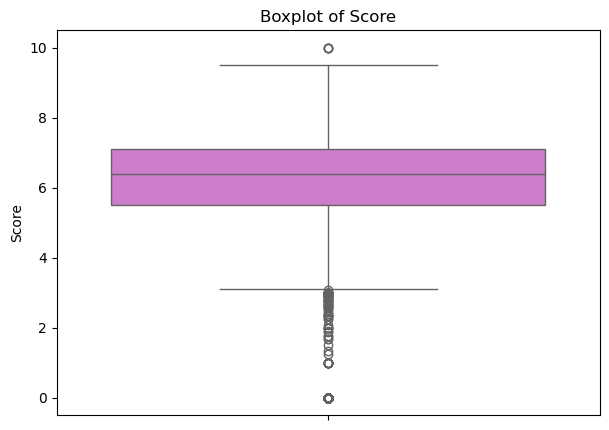

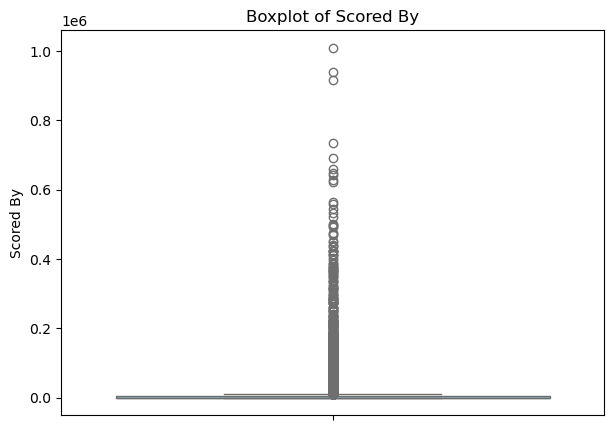

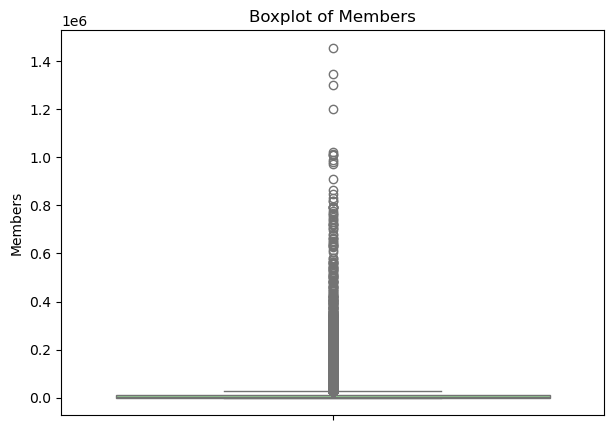

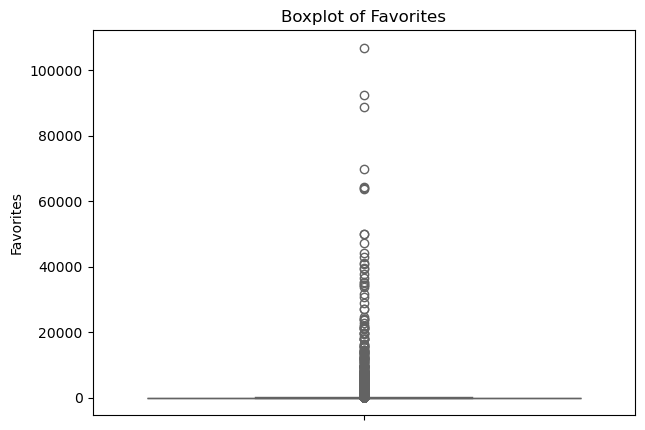

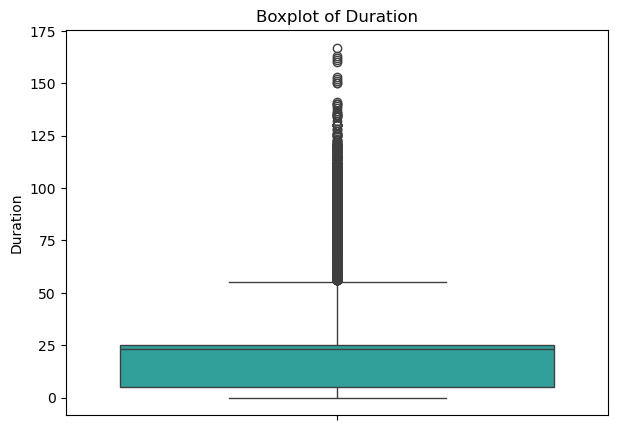

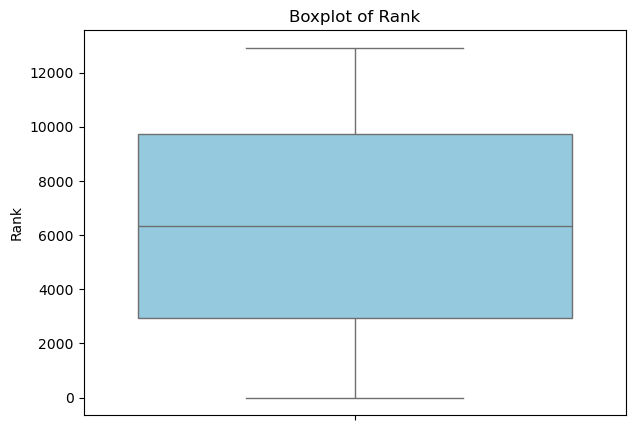

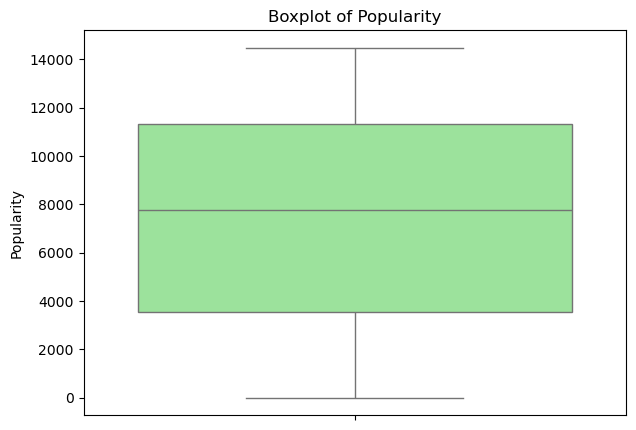

In [26]:
# Boxplot for each column to identify outliers properly

plt.figure(figsize=(7,5))
sns.boxplot(y=df['score'],color='orchid')
plt.title('Boxplot of Score')
plt.ylabel('Score')
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(y=df['scored_by'],color='skyblue')
plt.title('Boxplot of Scored By')
plt.ylabel('Scored By')
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(y=df['members'],color='lightgreen')
plt.title('Boxplot of Members')
plt.ylabel('Members')
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(y=df['favorites'],color='orchid')
plt.title('Boxplot of Favorites')
plt.ylabel('Favorites')
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(y=df['duration'],color='lightseagreen')
plt.title('Boxplot of Duration')
plt.ylabel('Duration')
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(y=df['rank'],color='skyblue')
plt.title('Boxplot of Rank')
plt.ylabel('Rank')
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(y=df['popularity'],color='lightgreen')
plt.title('Boxplot of Popularity')
plt.ylabel('Popularity')
plt.show()

In [27]:
# Since most of these columns have huge features therefore applying log1p() so that huge skewness gets removed from these columns

df['score_log'] = np.log1p(df['score'])
df['scored_by_log'] = np.log1p(df['scored_by'])
df['members_log'] = np.log1p(df['members'])
df['favorites_log'] = np.log1p(df['favorites'])
df['duration_log'] = np.log1p(df['duration'])

C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\1013136172.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['score_log'] = np.log1p(df['score'])
C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\1013136172.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['scored_by_log'] = np.log1p(df['scored_by'])
C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\1013136172.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

In [28]:
# Detecting outliers using IQR: favorites_log

Q1 = df['favorites_log'].quantile(0.25)
Q3 = df['favorites_log'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['favorites_log'] < lower_bound) | (df['favorites_log'] > upper_bound)]
print(f"Outliers count: {outliers.shape[0]}")

Outliers count: 325


In [29]:
# Capping outliers at upper bound as the number of outliers are more

df['favorites_log_capped'] = df['favorites_log'].apply(lambda x: upper_bound if x > upper_bound else x)

C:\Users\Dell\AppData\Local\Temp\ipykernel_12992\3149291125.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['favorites_log_capped'] = df['favorites_log'].apply(lambda x: upper_bound if x > upper_bound else x)


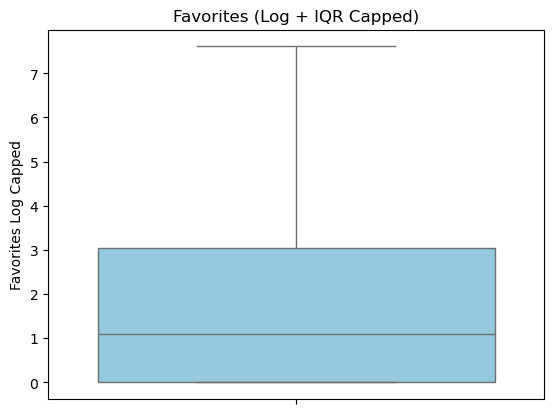

In [30]:
# Final Boxplot

sns.boxplot(y=df['favorites_log_capped'],color='skyblue')
plt.title("Favorites (Log + IQR Capped)")
plt.ylabel('Favorites Log Capped')
plt.show()

# Removing Extra Space From All The Columns

In [31]:
# Removing extra space from all the columns to make it look more clean

df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Rearranging All The Columns

In [32]:
# This is the current order of the columns

df.columns

Index(['anime_id', 'title', 'title_english', 'image_url', 'type', 'source',
       'episodes', 'status', 'duration', 'rating', 'score', 'scored_by',
       'rank', 'popularity', 'members', 'favorites', 'producer', 'studio',
       'genre', 'aired_start_date', 'aired_end_date', 'premiered_season',
       'premiered_year', 'score_log', 'scored_by_log', 'members_log',
       'favorites_log', 'duration_log', 'favorites_log_capped'],
      dtype='object')

In [33]:
# This arrangement of the columns makes more sense 

new_order= ['anime_id', 'title', 'title_english', 'image_url', 'type', 'source','episodes', 'status', 'premiered_season', 'premiered_year','aired_start_date', 'aired_end_date', 'duration', 'rating', 'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites', 'producer', 'studio','genre']
df=df[new_order]

# Final DataFrame

In [34]:
# The final DataFrame has been cleaned, organized, and is now ready for further analysis

df

,anime_id,title,title_english,image_url,type,source,episodes,status,premiered_season,premiered_year,...,rating,score,scored_by,rank,popularity,members,favorites,producer,studio,genre
0,1535,Death Note,Death Note,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,37,Finished Airing,Fall,2006.0,...,R - 17+ (violence & profanity),8.67,1009477,51,1,1456378,88696,"VAP, Konami, Ashi Production, Nippon Televisio...",Madhouse,"Mystery, Police, Psychological, Supernatural, ..."
1,16498,Shingeki no Kyojin,Attack on Titan,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,25,Finished Airing,Spring,2013.0,...,R - 17+ (violence & profanity),8.49,940211,110,2,1345842,64032,"Production I.G, Dentsu, Mainichi Broadcasting ...",Wit Studio,"Action, Military, Mystery, Super Power, Drama,..."
2,11757,Sword Art Online,Sword Art Online,https://myanimelist.cdn-dena.com/images/anime/...,TV,Light novel,25,Finished Airing,Summer,2012.0,...,PG-13 - Teens 13 or older,7.64,915986,1259,3,1301616,50042,"Aniplex, Genco, DAX Production, ASCII Media Works",A-1 Pictures,"Action, Adventure, Fantasy, Game, Romance"
3,5114,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,64,Finished Airing,Spring,2009.0,...,R - 17+ (violence & profanity),9.25,733592,1,4,1199091,106895,"Aniplex, Square Enix, Mainichi Broadcasting Sy...",Bones,"Action, Military, Adventure, Comedy, Drama, Ma..."
4,30276,One Punch Man,One Punch Man,https://myanimelist.cdn-dena.com/images/anime/...,TV,Web manga,12,Finished Airing,Fall,2015.0,...,R - 17+ (violence & profanity),8.73,691845,44,5,1020754,30747,"TV Tokyo, Bandai Visual, Lantis, Asatsu DK, Ba...",Madhouse,"Action, Sci-Fi, Comedy, Parody, Super Power, S..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14469,35853,Zero Seiki Movie 1: Emeraldas,Zero Seiki Movie 1: Emeraldas,https://myanimelist.cdn-dena.com/images/anime/...,Movie,Manga,1,Not yet aired,Unknown,1900.0,...,Unknown,0.00,0,-1,8406,936,0,Unknown,Unknown,"Action, Sci-Fi, Adventure"
14470,35854,Zero Seiki Movie 2: Herlock,Zero Seiki Movie 2: Herlock,https://myanimelist.cdn-dena.com/images/anime/...,Movie,Manga,1,Not yet aired,Unknown,1900.0,...,Unknown,0.00,0,-1,8700,799,1,Unknown,Unknown,"Action, Sci-Fi, Adventure"
14471,35855,Zero Seiki Movie 3: Maetel,Zero Seiki Movie 3: Maetel,https://myanimelist.cdn-dena.com/images/anime/...,Movie,Manga,1,Not yet aired,Unknown,1900.0,...,Unknown,0.00,0,-1,9223,594,0,Unknown,Unknown,"Action, Sci-Fi, Adventure"
14472,37395,Zoids Wild,Zoids Wild,https://myanimelist.cdn-dena.com/images/anime/...,TV,Unknown,0,Not yet aired,Summer,2018.0,...,PG - Children,0.00,0,-1,8604,840,1,Unknown,Unknown,"Action, Adventure, Comedy, Mecha, Sci-Fi"


# Converting To CSV File

In [35]:
# File name: cleaned_myanimelist

df.to_csv("myanimelist_cleaned.csv", index=False)